# Model Training, Selection & Threshold Optimization

In [22]:
%pip install ucimlrepo

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import os
from pathlib import Path
from datetime import datetime
import sklearn
import pandas as pd
import numpy as np
import joblib

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, 
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# ==========================================
# PRODUCTION CONFIGURATION & HYPERPARAMETERS
# ==========================================
RANDOM_STATE = 42
TEST_SIZE = 0.20
N_CV_FOLDS = 5
RECALL_FLOOR = 0.85
MODEL_ARTIFACT_NAME = "heart_disease_classifier.joblib"

# Feature definitions
NUMERICAL_COLS = ["age", "trestbps", "chol", "thalach", "oldpeak"]
CATEGORICAL_COLS = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

# Ensure reproducible random state across all dependencies
np.random.seed(RANDOM_STATE)


###  Data Ingestion and Stratified Train/Test Split

In [24]:
# 1. Fetch raw dataset directly to maintain single source of truth
print("Fetching raw dataset from UCI Repository...")
heart_disease = fetch_ucirepo(id=45)
X_raw = heart_disease.data.features.copy()
y_raw = heart_disease.data.targets.copy()

# Convert target to binary (0 = Healthy, 1 = Disease)
y_binary_raw = (y_raw['num'] > 0).astype(int).values.ravel()

# 2. Data Validation Checks
assert X_raw.shape[1] == len(NUMERICAL_COLS) + len(CATEGORICAL_COLS), "Feature count mismatch!"
assert np.isin(y_binary_raw, [0, 1]).all(), "Target is not binary!"
print(f"Data ingested successfully: {X_raw.shape[0]} patient records, {X_raw.shape[1]} raw features.")
print(f"Target Distribution -> Healthy: {(y_binary_raw==0).sum()}, Disease: {(y_binary_raw==1).sum()}")

# 3. Leakage-Free Stratified Train/Test Split
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, 
    y_binary_raw, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE, 
    stratify=y_binary_raw
)

print(f"Stratified Split completed -> X_train: {X_train_raw.shape}, X_test: {X_test_raw.shape}")


Fetching raw dataset from UCI Repository...
Data ingested successfully: 303 patient records, 13 raw features.
Target Distribution -> Healthy: 164, Disease: 139
Stratified Split completed -> X_train: (242, 13), X_test: (61, 13)


### Preprocessing and Candidate Pipelines Definitions

In [25]:
# 1. Define modular Transformers
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 2. Assemble unified ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, NUMERICAL_COLS),
    ('cat', categorical_transformer, CATEGORICAL_COLS)
])

# 3. Define candidate model pipelines (Preprocessor + Estimator)
def get_candidate_pipelines():
    return {
        "Logistic Regression": Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ]),
        "Random Forest": Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", RandomForestClassifier(random_state=RANDOM_STATE))
        ]),
        "SVM": Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", SVC(probability=True, random_state=RANDOM_STATE))
        ]),
        "Gradient Boosting": Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", GradientBoostingClassifier(random_state=RANDOM_STATE))
        ])
    }

candidate_pipelines = get_candidate_pipelines()
print(f"Initialized {len(candidate_pipelines)} end-to-end model pipelines.")


Initialized 4 end-to-end model pipelines.


In [26]:
# Define hyperparameter grid mapped to pipeline step names ('classifier__<param>')
param_grids = {
    "Logistic Regression": {
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear']
    },
    "SVM": {
        'classifier__C': [0.1, 1, 10, 100],
        'classifier__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
        'classifier__kernel': ['rbf', 'linear']
    },
    "Random Forest": {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [None, 5, 10, 15],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },
    "Gradient Boosting": {
        'classifier__n_estimators': [50, 100, 150],
        'classifier__learning_rate': [0.01, 0.05, 0.1],
        'classifier__max_depth': [3, 4, 5],
        'classifier__subsample': [0.8, 1.0]
    }
}

cv_strategy = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

tuned_pipelines = {}
print("Starting Hyperparameter Tuning on full pipelines (Optimizing AUC-ROC)...")
print(f"{'='*70}")

for name in param_grids.keys():
    print(f"\nTuning {name}...")
    grid_search = GridSearchCV(
        estimator=candidate_pipelines[name],
        param_grid=param_grids[name],
        cv=cv_strategy,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )
    grid_search.fit(X_train_raw, y_train_raw)
    tuned_pipelines[name] = grid_search.best_estimator_
    print(f"  Best Parameters : {grid_search.best_params_}")
    print(f"  Best CV AUC-ROC : {grid_search.best_score_:.4f}")


Starting Hyperparameter Tuning on full pipelines (Optimizing AUC-ROC)...

Tuning Logistic Regression...
  Best Parameters : {'classifier__C': 1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
  Best CV AUC-ROC : 0.9070

Tuning SVM...
  Best Parameters : {'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}
  Best CV AUC-ROC : 0.9047

Tuning Random Forest...
  Best Parameters : {'classifier__max_depth': 5, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 50}
  Best CV AUC-ROC : 0.9067

Tuning Gradient Boosting...
  Best Parameters : {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 150, 'classifier__subsample': 0.8}
  Best CV AUC-ROC : 0.8871


### Generating Out-of-Fold (OOF) Probabilities

In [27]:
print("Generating Out-of-Fold (OOF) probabilities for all tuned models...")
oof_probabilities = {}

for name, pipeline in tuned_pipelines.items():
    # Use cross_val_predict to get unbiased OOF probability predictions on train set
    oof_proba = cross_val_predict(
        pipeline,
        X_train_raw,
        y_train_raw,
        cv=cv_strategy,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]
    oof_probabilities[name] = oof_proba
    print(f"  OOF Probabilities generated for {name}.")


Generating Out-of-Fold (OOF) probabilities for all tuned models...
  OOF Probabilities generated for Logistic Regression.
  OOF Probabilities generated for SVM.
  OOF Probabilities generated for Random Forest.
  OOF Probabilities generated for Gradient Boosting.


### Threshold Sweep and Recall-Constrained Selection

In [28]:
thresholds = np.linspace(0.05, 0.95, 91)
model_sweeps = {}
model_selections = {}

print("Performing threshold sweep for all models...")

for name, oof_proba in oof_probabilities.items():
    sweep_results = []
    for t in thresholds:
        t_val = round(t, 2)
        preds = (oof_proba >= t_val).astype(int)
        
        rec = recall_score(y_train_raw, preds, zero_division=0)
        prec = precision_score(y_train_raw, preds, zero_division=0)
        f1 = f1_score(y_train_raw, preds, zero_division=0)
        acc = accuracy_score(y_train_raw, preds)
        
        sweep_results.append({
            "threshold": t_val,
            "recall": rec,
            "precision": prec,
            "f1": f1,
            "accuracy": acc,
            "meets_recall": rec >= RECALL_FLOOR
        })
    
    sweep_df = pd.DataFrame(sweep_results)
    model_sweeps[name] = sweep_df
    
    # Filter for recall constraint
    eligible = sweep_df[sweep_df["meets_recall"] == True]
    
    if eligible.empty:
        print(f"  WARNING: {name} did not meet the recall floor at any threshold.")
        model_selections[name] = None
    else:
        # Sort by precision (descending), then F1 (descending), then threshold (descending)
        sorted_eligible = eligible.sort_values(
            by=["precision", "f1", "threshold"], 
            ascending=[False, False, False]
        )
        best_selection = sorted_eligible.iloc[0].to_dict()
        model_selections[name] = best_selection
        print(f"  {name:20} -> Selected Threshold: {best_selection['threshold']:.2f} | Precision: {best_selection['precision']:.4f} | Recall: {best_selection['recall']:.4f}")


Performing threshold sweep for all models...
  Logistic Regression  -> Selected Threshold: 0.40 | Precision: 0.8190 | Recall: 0.8559
  SVM                  -> Selected Threshold: 0.30 | Precision: 0.7405 | Recall: 0.8739
  Random Forest        -> Selected Threshold: 0.39 | Precision: 0.7422 | Recall: 0.8559
  Gradient Boosting    -> Selected Threshold: 0.33 | Precision: 0.6690 | Recall: 0.8559


In [29]:
comparison_data = []

for name, pipeline in tuned_pipelines.items():
    selection = model_selections[name]
    
    # Calculate CV ROC-AUC from grid search outputs (stored in Grid Search parameters, but we can compute it on OOF here too)
    oof_auc = roc_auc_score(y_train_raw, oof_probabilities[name])
    
    if selection is not None:
        comparison_data.append({
            "Model": name,
            "Best Threshold": f"{selection['threshold']:.2f}",
            "OOF Recall": selection['recall'],
            "OOF Precision": selection['precision'],
            "OOF F1": selection['f1'],
            "OOF Accuracy": selection['accuracy'],
            "Meets Recall": "Yes",
            "OOF ROC-AUC": oof_auc
        })
    else:
        comparison_data.append({
            "Model": name,
            "Best Threshold": "N/A",
            "OOF Recall": 0.0,
            "OOF Precision": 0.0,
            "OOF F1": 0.0,
            "OOF Accuracy": 0.0,
            "Meets Recall": "No",
            "OOF ROC-AUC": oof_auc
        })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df)
# Save table as CSV
#comparison_df.to_csv("model_selection_comparison.csv", index=False)

print("\n================================================")


                 Model Best Threshold  OOF Recall  OOF Precision    OOF F1  \
0  Logistic Regression           0.40    0.855856       0.818966  0.837004   
1                  SVM           0.30    0.873874       0.740458  0.801653   
2        Random Forest           0.39    0.855856       0.742188  0.794979   
3    Gradient Boosting           0.33    0.855856       0.669014  0.750988   

   OOF Accuracy Meets Recall  OOF ROC-AUC  
0      0.847107          Yes     0.905715  
1      0.801653          Yes     0.899732  
2      0.797521          Yes     0.903308  
3      0.739669          Yes     0.882952  



### Selection of the Winning Model

In [30]:
# Filter to models that met the recall constraint
eligible_models = comparison_df[comparison_df["Meets Recall"] == "Yes"].copy()

if eligible_models.empty:
    raise RuntimeError("No models met the OOF Recall constraint of >= 0.85.")

# Sort according to selection criteria
winning_row = eligible_models.sort_values(
    by=["OOF Precision", "OOF F1", "OOF ROC-AUC"],
    ascending=[False, False, False]
).iloc[0]

winning_model_name = winning_row["Model"]
winning_threshold = float(winning_row["Best Threshold"])

print(f"WINNING MODEL SELECTED DETERMINISTICALLY:")
print(f"  Model Name       : {winning_model_name}")
print(f"  Locked Threshold : {winning_threshold:.2f}")
print(f"  OOF Precision    : {winning_row['OOF Precision']:.4f}")
print(f"  OOF Recall       : {winning_row['OOF Recall']:.4f}")
print(f"  OOF Accuracy       : {winning_row['OOF Accuracy']:.4f}")


WINNING MODEL SELECTED DETERMINISTICALLY:
  Model Name       : Logistic Regression
  Locked Threshold : 0.40
  OOF Precision    : 0.8190
  OOF Recall       : 0.8559
  OOF Accuracy       : 0.8471


FINAL HELD-OUT TEST SET EVALUATION (Unseen Data):
  Selected Model      : Logistic Regression
  Applied Threshold   : 0.40
  Accuracy            : 0.8852
  Recall (Sensitivity): 0.9643 (Missed cases (FN): 1 / 28)
  Precision           : 0.8182
  F1-Score            : 0.8852
  Confusion Matrix    : [TP: 27, FP: 6, FN: 1, TN: 27]


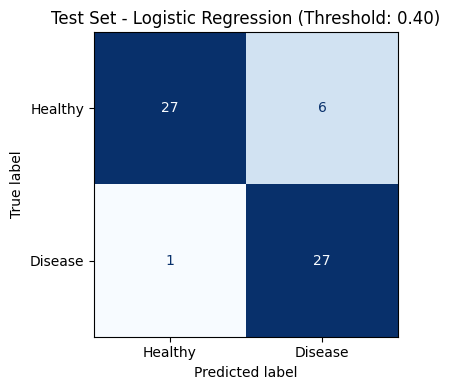

In [31]:
# 1. Retrieve the winning pipeline
winning_pipeline = tuned_pipelines[winning_model_name]

# 2. Refit the pipeline on all training data (242 samples)
winning_pipeline.fit(X_train_raw, y_train_raw)

# 3. Predict probabilities and apply the locked threshold on the test set
y_test_proba = winning_pipeline.predict_proba(X_test_raw)[:, 1]
y_test_pred = (y_test_proba >= winning_threshold).astype(int)

# 4. Evaluate metrics
test_accuracy = accuracy_score(y_test_raw, y_test_pred)
test_recall = recall_score(y_test_raw, y_test_pred)
test_precision = precision_score(y_test_raw, y_test_pred)
test_f1 = f1_score(y_test_raw, y_test_pred)
tn, fp, fn, tp = confusion_matrix(y_test_raw, y_test_pred).ravel()

print("FINAL HELD-OUT TEST SET EVALUATION (Unseen Data):")
print(f"  Selected Model      : {winning_model_name}")
print(f"  Applied Threshold   : {winning_threshold:.2f}")
print(f"  Accuracy            : {test_accuracy:.4f}")
print(f"  Recall (Sensitivity): {test_recall:.4f} (Missed cases (FN): {fn} / {tp+fn})")
print(f"  Precision           : {test_precision:.4f}")
print(f"  F1-Score            : {test_f1:.4f}")
print(f"  Confusion Matrix    : [TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}]")

# Confusion Matrix Visualization
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test_raw, y_test_pred), 
    display_labels=["Healthy", "Disease"]
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f"Test Set - {winning_model_name} (Threshold: {winning_threshold:.2f})")
plt.tight_layout()
plt.show()


In [32]:
'''
production_bundle = {
    "model": winning_pipeline,
    "optimal_threshold": winning_threshold,
    "threshold_method": "Recall-Constrained Precision Maximization on OOF Predictions",
    "recall_floor": RECALL_FLOOR,
    "oof_metrics": {
        "recall": float(winning_row["OOF Recall"]),
        "precision": float(winning_row["OOF Precision"]),
        "f1": float(winning_row["OOF F1"]),
        "accuracy": float(winning_row["OOF Accuracy"])
    },
    "features": list(X_train_raw.columns),
    "environment": {
        "sklearn_version": sklearn.__version__,
        "created_at": datetime.now().isoformat() + "Z"
    }
}

joblib.dump(production_bundle, MODEL_ARTIFACT_NAME)
print(f"Production model bundle successfully saved to '{MODEL_ARTIFACT_NAME}'!")
'''


'\nproduction_bundle = {\n    "model": winning_pipeline,\n    "optimal_threshold": winning_threshold,\n    "threshold_method": "Recall-Constrained Precision Maximization on OOF Predictions",\n    "recall_floor": RECALL_FLOOR,\n    "oof_metrics": {\n        "recall": float(winning_row["OOF Recall"]),\n        "precision": float(winning_row["OOF Precision"]),\n        "f1": float(winning_row["OOF F1"]),\n        "accuracy": float(winning_row["OOF Accuracy"])\n    },\n    "features": list(X_train_raw.columns),\n    "environment": {\n        "sklearn_version": sklearn.__version__,\n        "created_at": datetime.now().isoformat() + "Z"\n    }\n}\n\njoblib.dump(production_bundle, MODEL_ARTIFACT_NAME)\nprint(f"Production model bundle successfully saved to \'{MODEL_ARTIFACT_NAME}\'!")\n'